In [1]:
#install library dependencies
!pip install -qU langchain langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.4/477.4 kB 13.8 MB/s eta 0:00:00


In [2]:
from langchain_openai import ChatOpenAI #for LLM Service
from typing import Annotated, Literal #for Annotated and Literal data type

from typing_extensions import TypedDict #for TypedDict data type

from langgraph.graph import StateGraph, START, END #For create graph workflow
from langgraph.graph.message import add_messages #for messages operator

In [3]:
# Input API KEY
import getpass
import os

from google.colab import userdata

if not os.environ.get("OPENAI_API_KEY"):
  try:
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
  except:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

In [4]:
#define the LLM
llm = ChatOpenAI(
    model="gpt-4o-mini"
    )

In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    history: list

In [6]:
#define product_agent node
def product_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  products = '''Berikut ini list produk beserta detail keterangannya:
# Celana Panjang Pria
* **Harga:** Rp299.000
* **Deskripsi:** Beragam pilihan celana panjang pria, mulai dari jeans kasual hingga celana bahan formal. Cocok untuk berbagai kesempatan dan gaya.

# Pakaian Wanita
* **Harga:** Rp189.000
* **Deskripsi:** Koleksi pakaian wanita yang stylish dan nyaman, termasuk atasan, blouse, dan dress kasual. Tersedia dalam berbagai model dan warna untuk melengkapi penampilan Anda sehari-hari.

# Jaket
* **Harga:** Rp399.000
* **Deskripsi:** Jaket dengan berbagai model dan bahan, mulai dari jaket denim, bomber, hingga jaket *windbreaker*. Sempurna untuk menambah gaya dan memberikan kehangatan.

# Sepatu
* **Harga:** Rp450.000
* **Deskripsi:** Beragam jenis sepatu untuk pria dan wanita, termasuk *sneakers*, *loafers*, hingga sepatu formal. Desain trendi dengan kenyamanan optimal untuk aktivitas Anda.

# Tas
* **Harga:** Rp250.000
* **Deskripsi:** Pilihan tas fungsional dan modis seperti tas selempang, ransel, atau *tote bag*. Ideal untuk menemani aktivitas harian Anda, dari bekerja hingga bepergian santai.
'''

  prompt = f'''Kamu adalah chatbot yang membantu pelanggan dalam percakapan tentang produk fashion dari "Toko Pakaian Purwadhika".
Jawab pertanyaan dengan ramah dan sopan, serta persuasif dalam menawarkan barang kepada pelanggan. Gunakan chat history untuk membantu menangkap konteks percakapan.
Berikut ini list produk yang dijual oleh Toko Pakaian Purwadhika beserta detail keterangannya:
{products}

chat history: {history}
question: {question}
'''

  response = llm.invoke(prompt)
  return {"messages": [response]}

In [7]:
#define promo agent node
def promo_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  promo = '''Berikut ini list promo beserta detail keterangannya:
* Senin: Discount 50% untuk semua produk!
* Selasa: Gratis ongkir untuk pembelian di atas Rp100.000!
* Rabu: Buy 2 Get 1 Free untuk semua produk!
* Kamis: Gratis ongkir untuk pembelian di atas Rp50.000!
* Jumat: Discount 30% untuk semua produk!
* Sabtu: Gratis ongkir untuk pembelian di atas Rp75.000!
* Minggu: Discount 20% untuk semua produk!
'''

  prompt = f'''Kamu adalah chatbot yang membantu pelanggan dalam percakapan tentang promo yang ditawarkan oleh "Toko Pakaian Purwadhika".
Jawab pertanyaan dengan ramah dan sopan. Gunakan chat history untuk membantu menangkap konteks percakapan.
Berikut ini list promo yang ditawarkan oleh Toko Pakaian Purwadhika beserta detail keterangannya:
{promo}

chat history: {history}
question: {question}
'''

  response = llm.invoke(prompt)
  return {"messages": [response]}

In [8]:
#define basic agent node
def basic_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  prompt = f'''Kamu adalah chatbot "Toko Pakaian Purwadhika" yang akan membantu menjawab pertanyaan pelanggan.
Jawab pertanyaan dengan ramah dan sopan. Gunakan chat history untuk membantu menangkap konteks percakapan.
chat history: {history}
question: {question}
'''
  response = llm.invoke(prompt)
  return {"messages": [response]}

In [9]:
#define filter agent node
def filter_agent(state: State):
  question = state["messages"][0]
  history = state["history"]

  prompt = f'''Kamu adalah agent yang ditugaskan untuk mengklasifikasikan pertanyaan pelanggan menjadi tiga kategori yaitu ["product", "promo", "other"]. Kamu hanya bisa memilih antara tiga kategori tersebut.
Gunakan chat history untuk membantu dalam mengklasifikasikan pertanyaan pelanggan. Jawab hanya nama kategorinya saja.
chat history: {history}
question: {question}'''

  response = llm.invoke(prompt)
  return {"messages": [response]}

In [10]:
#define flow classifier
def classify_flow(state: State)->Literal["product_agent", "promo_agent", "basic_agent"]:
  msg = state["messages"][-1].content
  if msg == "product":
    return "product_agent"
  elif msg == "promo":
    return "promo_agent"
  else:
    return "basic_agent"

In [11]:
#create the workflow, connecting all nodes and rule of the flow
workflow = StateGraph(State)

workflow.add_node("filter_agent", filter_agent)
workflow.add_node("product_agent", product_agent)
workflow.add_node("promo_agent", promo_agent)
workflow.add_node("basic_agent", basic_agent)

workflow.add_edge(START, "filter_agent")
workflow.add_conditional_edges("filter_agent", classify_flow)
workflow.add_edge("product_agent", END)
workflow.add_edge("promo_agent", END)
workflow.add_edge("basic_agent", END)

app = workflow.compile()

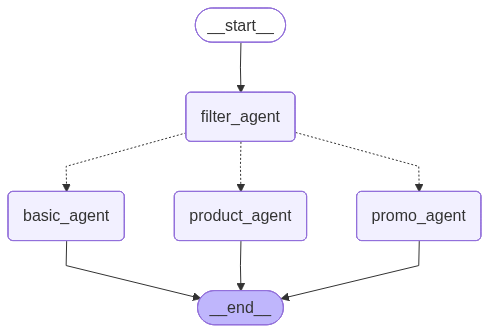

In [12]:
#show the workflow schema
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
#define the state
state_prompt = {
    "messages": [{"role": "user", "content": "produk apa yang cocok dengan pria?"}],
    "history": []
}

In [14]:
#run the agent
agent_response = app.invoke(state_prompt)

In [15]:
#check the response
agent_response['messages'][-1].content

'Halo! Terima kasih telah menghubungi Toko Pakaian Purwadhika. Untuk pria, kami memiliki beberapa produk yang sangat cocok. Berikut adalah beberapa pilihan yang bisa Anda pertimbangkan:\n\n1. **Celana Panjang Pria** - Tersedia dalam berbagai model, mulai dari jeans kasual hingga celana formal. Harganya hanya Rp299.000! Ini sangat cocok untuk berbagai kesempatan.\n\n2. **Jaket** - Kami juga memiliki jaket dengan berbagai model seperti denim, bomber, dan windbreaker dengan harga Rp399.000. Ini bisa jadi pilihan sempurna untuk menambah gaya dan memberikan kehangatan.\n\n3. **Sepatu** - Jika Anda mencari sepatu, kami menyediakan berbagai jenis seperti sneakers dan sepatu formal dengan harga Rp450.000. Desainnya trendi dan sangat nyaman!\n\nApakah ada produk tertentu yang menarik perhatian Anda, atau ingin informasi lebih lanjut tentang salah satu produk tersebut?'

In [16]:
# run with stream
agent_response = app.stream(state_prompt)
for response in agent_response:
  print(response)

{'filter_agent': {'messages': [AIMessage(content='product', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 116, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CpWISM33fcIIogTu07612Lz3nD00N', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b4557-5d8f-77d3-9ef4-c44a30072e1e-0', usage_metadata={'input_tokens': 116, 'output_tokens': 1, 'total_tokens': 117, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
{'product_agent': {'messages': [AIMessage(content='Halo! Terima kasih telah menghubungi Toko Pakaian Purwadhika. Untuk pria, k

In [17]:
#use llm with multi-turn interaction
history = []
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        prompt = {
            "messages": [{"role": "user", "content": user_input}],
            "history": history
        }
        answer = app.invoke(prompt)["messages"][-1].content
        print(f"AI: {answer}")
        history.append(f"User: {user_input}")
        history.append(f"AI: {answer}")
        # print(prompt)
    except:
        # fallback if input() is not available
        user_input = "Bad Input"
        print("User: " + user_input)
        break

User: ada produk apa aja nih yang cocok untuk pria?
AI: Halo! Di Toko Pakaian Purwadhika, kami memiliki beberapa produk yang cocok untuk pria. Berikut adalah pilihan yang bisa Anda pertimbangkan:

1. **Celana Panjang Pria** - Harganya Rp299.000. Kami memiliki beragam pilihan, mulai dari jeans kasual hingga celana bahan formal yang cocok untuk berbagai kesempatan dan gaya.

2. **Jaket** - Dengan harga Rp399.000, kami menawarkan jaket dalam berbagai model dan bahan, seperti jaket denim, bomber, dan windbreaker. Ini sempurna untuk menambah gaya sekaligus memberikan kehangatan.

3. **Sepatu** - Kami juga memiliki berbagai jenis sepatu untuk pria seharga Rp450.000, termasuk sneakers dan loafers. Desain yang trendi dan kenyamanan optimal siap menemani aktivitas Anda.

Apakah ada yang menarik perhatian Anda dari pilihan di atas? Jika Anda memiliki pertanyaan lebih lanjut atau butuh rekomendasi, jangan ragu untuk bertanya!
User: ok makasih
AI: Sama-sama! Jika Anda ada pertanyaan lain atau butu